<a href="https://colab.research.google.com/github/AntonRvn/ML_and_DNN_Lab/blob/main/Lab1_ML_and_DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q torchmetrics

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torchmetrics

**OR**

In [ ]:
"""# **Обучение нейрона выполнению функции логического "ИЛИ"**"""

# Входные данные
X = torch.tensor([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]], dtype=torch.float32)

# Желаемый выход для логической операции OR
Y = torch.tensor([[0],
                  [1],
                  [1],
                  [1]], dtype=torch.float32)

In [ ]:
# Вспомогательная функция для отрисовки границы решения
def plot_decision_boundary(model, X, y):
    X = X.numpy()
    y = y.numpy()
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx1, xx2 = np.meshgrid(np.linspace(x_min, x_max, 500),
                           np.linspace(y_min, y_max, 500))
    x_in = np.c_[xx1.ravel(), xx2.ravel()]

    # Преобразуем данные для предсказания
    x_in_tensor = torch.tensor(x_in, dtype=torch.float32)
    with torch.no_grad():
        y_pred = model(x_in_tensor).numpy()

    y_pred = np.round(y_pred).reshape(xx1.shape)

    plt.contourf(xx1, xx2, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.pause(0.01)

In [ ]:
# Модель нейрона
class Perceptron(nn.Module):

    def __init__(self, input_size):
        """
        Конструктор.
        Определяем слои, входящие в модель.
        """

        super(Perceptron, self).__init__()

        # Линейный слой с одним нейроном
        self.fc = nn.Linear(input_size, 1)

    def forward(self, x):
        """
        Основной метод прямого прохода.
        """

        # Передаём входные данные в нейрон
        z = self.fc(x)

        # Сигмоидальная функция активации
        p = torch.sigmoid(z)

        return p

In [ ]:
def train_model(X, Y, epochs=1000):
    model = Perceptron(input_size=2)

    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(epochs):
        outputs = model(X)
        loss = criterion(outputs, Y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            predicted = (outputs >= 0.5).float()
            accuracy = (predicted == Y).float().mean()

        print(f"Epoch [{epoch + 1}/{epochs}], "
        f"Loss: {loss.item():.4f}, "
        f"Accuracy: {accuracy.item():.4f}")
        # Визуализируем границу решения
        plot_decision_boundary(model, X, Y)

    return model


In [ ]:
# Функция тестирования модели
def test_model(X_test, model):
    model.eval() # переключение модели в режим "тестирования" (evaluation mode)
    with torch.no_grad(): # отключаем вычисление градиентов для экономии ресурсов
        result = model(X_test) # предсказание для входных тестовых данных
    print("Выходная вероятность: " + str(result))
    # Задаётся решающее правило.
    if(result >= 0.5): # если выходная вероятность предсказания больше или равно 0.5 то возвращаем класс 1
      return 1
    elif(result < 0.5): # если выходная вероятность предсказания меньше 0.5 то возвращаем класс 0
      return 0

In [ ]:
# Запуск обучения
model_or = train_model(X, Y, epochs=1000)

In [ ]:
# Проверка всех вариантов
X_test = torch.tensor([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=torch.float32)

for x in X_test:
    print(
        f"Вход: {x.tolist()} -> "
        f"Результат: {test_model(x.unsqueeze(0), model_or)}"
    )

Выходная вероятность: tensor([[0.1392]])
Вход: [0.0, 0.0] -> Результат: 0
Выходная вероятность: tensor([[0.9410]])
Вход: [0.0, 1.0] -> Результат: 1
Выходная вероятность: tensor([[0.9361]])
Вход: [1.0, 0.0] -> Результат: 1
Выходная вероятность: tensor([[0.9993]])
Вход: [1.0, 1.0] -> Результат: 1


In [ ]:
# Получение всех весов модели
for name, param in model_or.state_dict().items():
    print(f"Layer: {name} | Weights: {param}")

Layer: fc.weight | Weights: tensor([[4.5069, 4.5914]])
Layer: fc.bias | Weights: tensor([-1.8224])


**XOR 1 нейрон**

In [ ]:
"""# **Попытка обучения одного нейрона выполнению XOR**"""

# Входные данные
X = torch.tensor([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]], dtype=torch.float32)

# Желаемый выход для логической операции XOR
Y = torch.tensor([[0],
                  [1],
                  [1],
                  [0]], dtype=torch.float32)

In [ ]:
# Попытка обучения XOR одним нейроном
model_xor_one_neuron = train_model(X, Y, epochs=1000)

In [ ]:
# Проверка результатов
X_test = torch.tensor([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=torch.float32)

for x in X_test:
    print(
        f"Вход: {x.tolist()} -> "
        f"Результат: {test_model(x.unsqueeze(0), model_xor_one_neuron)}"
    )

Выходная вероятность: tensor([[0.5000]])
Вход: [0.0, 0.0] -> Результат: 1
Выходная вероятность: tensor([[0.5000]])
Вход: [0.0, 1.0] -> Результат: 1
Выходная вероятность: tensor([[0.5000]])
Вход: [1.0, 0.0] -> Результат: 1
Выходная вероятность: tensor([[0.5000]])
Вход: [1.0, 1.0] -> Результат: 1


In [ ]:
# Получение всех весов модели
for name, param in model_xor_one_neuron.state_dict().items():
    print(f"Layer: {name} | Weights: {param}")

Layer: fc.weight | Weights: tensor([[ 1.4141e-07, -1.1693e-08]])
Layer: fc.bias | Weights: tensor([-8.6486e-08])


In [ ]:
"""# **Построение модели для решения XOR**"""

# Входные данные
X = torch.tensor([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]], dtype=torch.float32)

# Желаемый выход XOR
Y = torch.tensor([[0],
                  [1],
                  [1],
                  [0]], dtype=torch.float32)

**XOR 2 нейрона**

In [ ]:
class XORPerceptron(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(2, 2)
        self.layer2 = nn.Linear(2, 1)

    def forward(self, x):
        x = torch.sigmoid(self.layer1(x))
        x = torch.sigmoid(self.layer2(x))
        return x

In [ ]:
# Функция тренировки модели XOR
def train_xor_model(X, Y, epochs=2000):

    model = XORPerceptron()

    model.train()

    # Функция ошибки бинарной классификации
    criterion = nn.BCELoss()

    metric = torchmetrics.Accuracy(
        task='binary',
        threshold=0.5
    )

    # Оптимизатор
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.01
    )

    for epoch in range(epochs):

        # Прямой проход
        outputs = model(X)

        # Вычисление ошибки
        loss = criterion(outputs, Y)

        # Вычисление точности
        accuracy = metric(
            outputs.detach(),
            Y.int()
        )

        # Обратное распространение ошибки
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        print(f"Epoch [{epoch + 1}/{epochs}], "
        f"Loss: {loss.item():.4f}, "
        f"Accuracy: {accuracy.item():.4f}")
        # Визуализируем границу решения
        plot_decision_boundary(model, X, Y)

    return model

In [ ]:
# Запуск обучения модели XOR
model_xor = train_xor_model(X, Y, epochs=2000)

In [ ]:
# Проверка обученной модели XOR

X_test = torch.tensor([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=torch.float32)

model_xor.eval()

with torch.no_grad():

    result = model_xor(X_test)

print("Результаты классификации:\n")

for i in range(len(X_test)):

    probability = result[i].item()

    if probability > 0.5:
        prediction = 1
    else:
        prediction = 0

    expected = int(
        Y[i].item()
    )

    print(
        f"Вход: {X_test[i].tolist()} | "
        f"Вероятность: {probability:.4f} | "
        f"Предсказание: {prediction} | "
        f"Ожидаемый класс: {expected}"
    )

Результаты классификации:

Вход: [0.0, 0.0] | Вероятность: 0.0111 | Предсказание: 0 | Ожидаемый класс: 0
Вход: [0.0, 1.0] | Вероятность: 0.9885 | Предсказание: 1 | Ожидаемый класс: 1
Вход: [1.0, 0.0] | Вероятность: 0.9885 | Предсказание: 1 | Ожидаемый класс: 1
Вход: [1.0, 1.0] | Вероятность: 0.0170 | Предсказание: 0 | Ожидаемый класс: 0


In [ ]:
# Получение всех весов модели
for name, param in model_xor.state_dict().items():
    print(f"Layer: {name} | Weights: {param}")

Layer: layer1.weight | Weights: tensor([[-8.7469, -8.7214],
        [-7.3004, -7.2956]])
Layer: layer1.bias | Weights: tensor([ 3.9043, 10.7815])
Layer: layer2.weight | Weights: tensor([[-9.4692,  9.0441]])
Layer: layer2.bias | Weights: tensor([-4.2497])


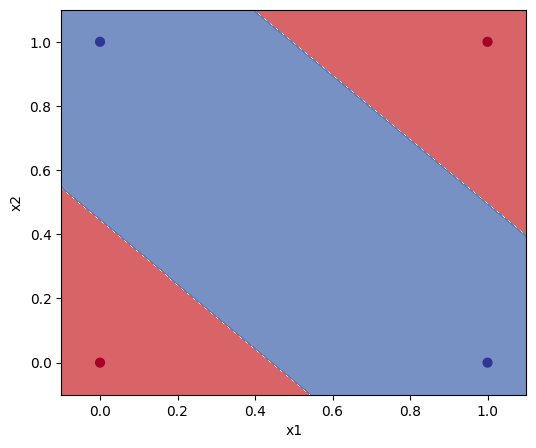

In [ ]:
# Визуализация границы решения для XOR

plt.figure(figsize=(6, 5))

plot_decision_boundary(
    model_xor,
    X,
    Y
)

plt.show()

In [ ]:
"""# **Построение графика пороговой функции**"""

# Пороговая функция
def threshold_function(x):

    if x <= 0:
        return 0
    else:
        return 1

In [ ]:
act_x = np.linspace(-1, 1, 101)

act_y = [
    threshold_function(x)
    for x in act_x
]

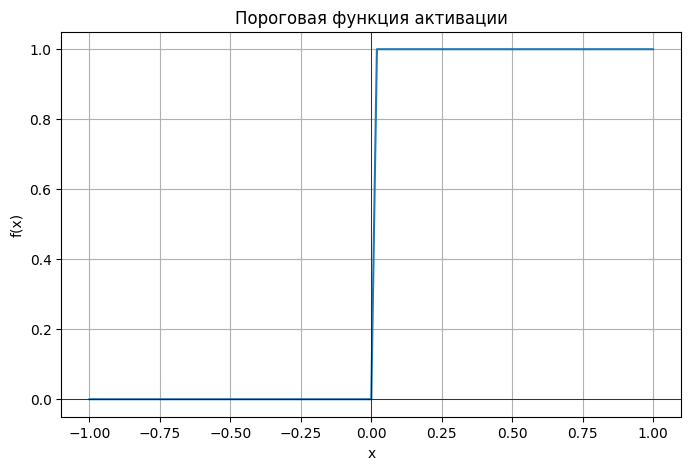

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    act_x,
    act_y
)

# Добавление осей x и y
plt.axhline(
    0,
    color='black',
    linewidth=0.5
)

plt.axvline(
    0,
    color='black',
    linewidth=0.5
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Пороговая функция активации")

plt.grid(True)

plt.show()